# Online Retailer A/B Test — Decco

## Executive summary
Decco tested an in-app promotional notification for its new **Lamps** category. The experiment evaluates whether the notification increases purchasing behavior without causing an unacceptable increase in app uninstalls.

This notebook follows a product-experimentation workflow: **experiment design → power → data quality → experiment health → treatment effects → business impact → covariate adjustment → exploratory heterogeneity → recommendation**.


## 1. Business context and experiment design

Decco is an online home-decor retailer that recently introduced Lamps. Based on prior success with in-app notifications, the treatment sends users a promotional Lamps offer; control users do not receive that treatment.

### Hypothesis
**If** Decco sends an in-app Lamps promotion, **then** transaction rate will increase because the notification increases awareness and purchase intent.

### Metrics
- **Primary:** transaction rate
- **Secondary:** average purchase value among purchasers
- **Guardrail:** uninstall rate
- **Funnel Diagnostic:** add-to-cart rate
- **Additional business outcome:** revenue per randomized user


### Pre-specified design assumptions
- Significance level: **5%** (95% confidence)
- Power: **80%**
- Historical transaction baseline: **10.1%**
- Minimum detectable effect (MDE): **20% relative lift**

### Decision framework
The treatment should not be judged on statistical significance alone. A rollout decision should consider whether the transaction/revenue improvement is practically meaningful **and** whether the increase in the uninstall guardrail is economically acceptable. The dataset does not provide exact customer lifetime value or profit margins, so the economic trade-off cannot be fully monetized; the rollout decision will therefore combine the observed experiment effects with the company's stated priority of protecting long-term user value.

### Data
The dataset contains 100,000 app users observed during the experiment. Variables include treatment allocation, recent activity, days since activity, add-to-cart, transaction, purchase value, and uninstall outcomes.

**Source:** Data provided by Preeti Semwal in the Udemy course *Complete Course on A/B Testing*. The original tutorial used R; this notebook reworks the analysis in Python and extends it with experiment-health checks and product decision analysis.


## 2. Setup

In [1]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chisquare, ttest_ind
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest, confint_proportions_2indep
from statsmodels.stats.weightstats import CompareMeans, DescrStatsW
import statsmodels.formula.api as smf

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## 3. Power and sample-size requirement


In [2]:
control_rate = 0.101
relative_mde = 0.20
variant_rate = control_rate * (1 + relative_mde)

# Cohen's h for two proportions
effect_size = proportion_effectsize(control_rate, variant_rate)

power_analysis = NormalIndPower()
n_per_group = math.ceil(power_analysis.solve_power(
    effect_size=effect_size,
    power=0.80,
    alpha=0.05,
    ratio=1
))

print(f'Baseline rate: {control_rate:.1%}')
print(f'Target rate at 20% relative MDE: {variant_rate:.2%}')
print(f'Required sample per group: {n_per_group:,}')
print(f'Required total sample: {2*n_per_group:,}')

Baseline rate: 10.1%
Target rate at 20% relative MDE: 12.12%
Required sample per group: 3,792
Required total sample: 7,584


`NormalIndPower.solve_power()` returns the required sample size for the first group when `ratio=1`. Therefore the result is approximately **3,792 users per group (~7,584 total)**, not 3,792 total. With 100,000 observations and a 50/50 split, the realized experiment is comfortably above this requirement.


## 4. Load and validate the data


In [3]:
DATA_PATH = Path("data") / "_AB_Test_Data.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. "
        "See data/README.md for data access instructions."
    )

df = pd.read_csv(DATA_PATH)

In [4]:
print(df.shape)
df.head()

(100000, 8)


,userid,allocation,active_6m,days_since,addtocart_flag,transaction_flag,purchase_value,uninstall_flag
0,257597,treatment,0,236,0,0,NaN,0
1,992329,treatment,1,37,0,0,NaN,0
2,111016,control,1,41,0,0,NaN,0
3,483717,treatment,1,18,0,0,NaN,0
4,951259,control,0,256,0,0,NaN,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   userid            100000 non-null  int64  
 1   allocation        100000 non-null  object 
 2   active_6m         100000 non-null  int64  
 3   days_since        100000 non-null  int64  
 4   addtocart_flag    100000 non-null  int64  
 5   transaction_flag  100000 non-null  int64  
 6   purchase_value    13820 non-null   float64
 7   uninstall_flag    100000 non-null  int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 6.1+ MB


In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
userid,"100,000.0000",NaN,NaN,NaN,"687,531.4324","405,920.2202",17.0000,"335,248.0000","672,438.0000","1,042,749.0000","1,407,576.0000"
allocation,100000,2,treatment,50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
active_6m,"100,000.0000",NaN,NaN,NaN,0.7500,0.4330,0.0000,0.7500,1.0000,1.0000,1.0000
days_since,"100,000.0000",NaN,NaN,NaN,135.2376,98.7095,2.0000,60.0000,112.0000,180.2500,365.0000
addtocart_flag,"100,000.0000",NaN,NaN,NaN,0.2563,0.4366,0.0000,0.0000,0.0000,1.0000,1.0000
transaction_flag,"100,000.0000",NaN,NaN,NaN,0.1382,0.3451,0.0000,0.0000,0.0000,0.0000,1.0000
purchase_value,"13,820.0000",NaN,NaN,NaN,304.5757,117.4332,10.9974,226.1597,306.6985,384.0476,961.9966
uninstall_flag,"100,000.0000",NaN,NaN,NaN,0.0401,0.1962,0.0000,0.0000,0.0000,0.0000,1.0000


### Missingness check
`purchase_value` is expected to be missing for users who did not transact. We verify that this missingness follows the business logic rather than treating it as ordinary missing data.

In [6]:
missing = df.isna().mean().sort_values(ascending=False).rename('missing_rate')
display(missing.to_frame())

purchase_missing_check = pd.crosstab(
    df['transaction_flag'],
    df['purchase_value'].isna(),
    normalize='index'
)
display(purchase_missing_check)

,missing_rate
purchase_value,0.8618
userid,0.0000
allocation,0.0000
active_6m,0.0000
days_since,0.0000
addtocart_flag,0.0000
transaction_flag,0.0000
uninstall_flag,0.0000


purchase_value,False,True
transaction_flag,,
0,0.0000,1.0000
1,1.0000,0.0000


If purchase value is only observed for purchasers, analyses of `purchase_value` answer a **conditional** question: how much observed purchasers spent. Because purchasing is itself affected by treatment, purchaser-only AOV is not the cleanest overall causal business metric. We therefore also create **revenue per randomized user**, assigning zero revenue to non-purchasers.

In [7]:
df['revenue_per_user'] = df['purchase_value'].fillna(0)

## 5. Exploratory distributions


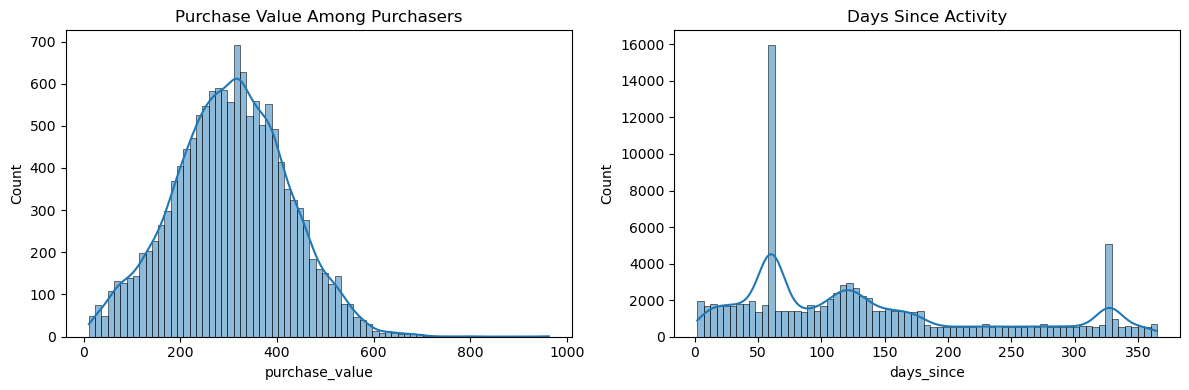

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['purchase_value'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Purchase Value Among Purchasers')

sns.histplot(df['days_since'], kde=True, ax=axes[1])
axes[1].set_title('Days Since Activity')
plt.tight_layout()
plt.show()

Distribution plots are descriptive only. Any peaks in `days_since` may reflect user behavior, campaign timing, or data-generation processes; the provided data do not identify their cause, so no causal explanation is assigned to them.


## 6. Experiment health and randomization checks


Before estimating treatment effects, check that the experiment appears healthy:
1. allocation matches the intended 50/50 split;
2. there is no **sample ratio mismatch (SRM)**;
3. observed pre-treatment covariates are reasonably balanced.

Balance checks do not prove randomization; they can reveal obvious implementation problems.

In [9]:
allocation_counts = df['allocation'].value_counts().reindex(['control', 'treatment'])
display(allocation_counts.to_frame('n'))
display((allocation_counts / allocation_counts.sum()).to_frame('share'))

,n
allocation,
control,50000
treatment,50000


,share
allocation,
control,0.5000
treatment,0.5000


In [10]:
# SRM chi-square test against the intended 50/50 allocation
expected = np.repeat(allocation_counts.sum() / 2, 2)

srm_stat, srm_p = chisquare(allocation_counts.values, f_exp=expected)

print(f'SRM chi-square: {srm_stat:.4f}')
print(f'SRM p-value: {srm_p:.4g}')

SRM chi-square: 0.0000
SRM p-value: 1


SRM shows whether an observed allocation differs more from the intended split than we would reasonably expect from random variation. For example, a seemingly innocuous 50.5% / 49.5% split across 100,000 observations would produce a p-value of ~0.0016, indicating a statistically significant mismatch from the expected 50/50 allocation.

active_6m        days_since        
                mean    std       mean     std
allocation                                    
control       0.7502 0.4329   135.0805 98.7257
treatment     0.7498 0.4331   135.3947 98.6940

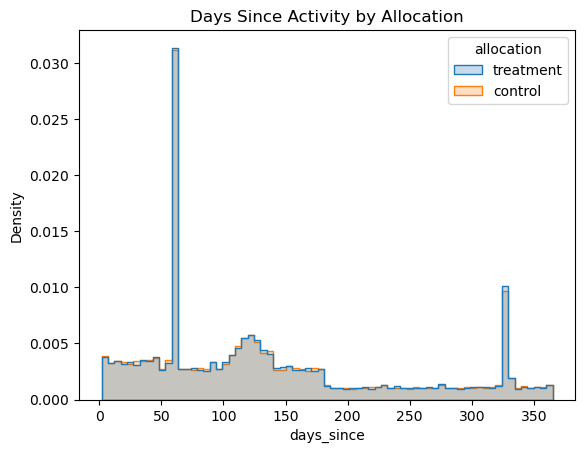

In [11]:
balance = df.groupby('allocation')[['active_6m', 'days_since']].agg(['mean', 'std'])
display(balance)

sns.histplot(data=df, x='days_since', hue='allocation', element='step', stat='density', common_norm=False)
plt.title('Days Since Activity by Allocation')
plt.show()

Allocation is exactly **50,000 control / 50,000 treatment**, and the observed baseline means were nearly identical (`active_6m`: 0.7502 vs 0.7498; `days_since`: 135.08 vs 135.39). This provides no obvious evidence of an allocation problem in the observed covariates.

## 7. Unadjusted treatment effects


For each binary outcome, report both:
- **absolute effect** in percentage points, and
- **relative lift** versus control.

This avoids conflating a percentage-point difference with a percent change.


### 7.1 Transaction Rate - Primary Metric

In [12]:
# Transaction rate by allocation
transaction_table = (df.groupby('allocation')['transaction_flag'].agg(['count', 'sum', 'mean'])
      .rename(columns={'count': 'n','sum': 'transactions','mean': 'transaction_rate'
      })
)

transaction_table['transaction_rate'] *= 100
transaction_table

,n,transactions,transaction_rate
allocation,,,
control,50000,5059,10.1180
treatment,50000,8761,17.5220


In [13]:
transaction_control_rate = transaction_table.loc['control', 'transaction_rate']
transaction_treatment_rate = transaction_table.loc['treatment', 'transaction_rate']

transaction_absolute_lift = transaction_treatment_rate - transaction_control_rate
transaction_relative_lift = (transaction_treatment_rate / transaction_control_rate - 1) * 100

print(f'Absolute lift: {transaction_absolute_lift:.2f} percentage points')
print(f'Relative lift: {transaction_relative_lift:.2f}%')

Absolute lift: 7.40 percentage points
Relative lift: 73.18%


In [14]:
successes = np.array([
    transaction_table.loc['treatment', 'transactions'],
    transaction_table.loc['control', 'transactions']
])

nobs = np.array([
    transaction_table.loc['treatment', 'n'],
    transaction_table.loc['control', 'n']
])

z_stat, p_value = proportions_ztest(successes, nobs)

ci_low, ci_high = confint_proportions_2indep(
    count1=successes[0],
    nobs1=nobs[0],
    count2=successes[1],
    nobs2=nobs[1],
    method='wald'
)

print(f'Z-statistic: {z_stat:.2f}')
print(f'P-value: {p_value:.4g}')
print(f'95% CI: [{ci_low * 100:.2f}, {ci_high * 100:.2f}] percentage points')

Z-statistic: 33.92
P-value: 3.177e-252
95% CI: [6.98, 7.83] percentage points


**Interpretation:** The positive confidence interval excludes zero, providing strong evidence that treatment increased transaction rate relative to control.

### 7.2 Add-to-cart rate — Funnel diagnostic

In [15]:
addtocart_table = (
    df.groupby('allocation')['addtocart_flag'].agg(['count', 'sum', 'mean'])
      .rename(columns={'count': 'n', 'sum': 'add_to_cart', 'mean': 'add_to_cart_rate'
      })
)

addtocart_table['add_to_cart_rate'] *= 100
addtocart_table

,n,add_to_cart,add_to_cart_rate
allocation,,,
control,50000,11785,23.5700
treatment,50000,13849,27.6980


In [16]:
add_to_cart_control_rate = addtocart_table.loc['control', 'add_to_cart_rate']
add_to_cart_treatment_rate = addtocart_table.loc['treatment', 'add_to_cart_rate']

add_to_cart_absolute_lift = add_to_cart_treatment_rate - add_to_cart_control_rate
add_to_cart_relative_lift = (add_to_cart_treatment_rate / add_to_cart_control_rate - 1) * 100

print(f'Absolute lift: {add_to_cart_absolute_lift:.2f} percentage points')
print(f'Relative lift: {add_to_cart_relative_lift:.2f}%')

Absolute lift: 4.13 percentage points
Relative lift: 17.51%


In [17]:
successes = np.array([
    addtocart_table.loc['treatment', 'add_to_cart'],
    addtocart_table.loc['control', 'add_to_cart']
])

nobs = np.array([
    addtocart_table.loc['treatment', 'n'],
    addtocart_table.loc['control', 'n']
])

z_stat, p_value = proportions_ztest(successes, nobs)

ci_low, ci_high = confint_proportions_2indep(
    count1=successes[0],
    nobs1=nobs[0],
    count2=successes[1],
    nobs2=nobs[1],
    method='wald'
)

print(f'Z-statistic: {z_stat:.2f}')
print(f'P-value: {p_value:.4g}')
print(f'95% CI: [{ci_low * 100:.2f}, {ci_high * 100:.2f}] percentage points')

Z-statistic: 14.95
P-value: 1.579e-50
95% CI: [3.59, 4.67] percentage points


**Interpretation:** Treatment also increased add-to-cart behavior, suggesting that the effect is visible earlier in the purchase funnel as well as in completed transactions.

### 7.3 Uninstall rate — Guardrail

In [18]:
uninstall_table = (
    df.groupby('allocation')['uninstall_flag'].agg(['count', 'sum', 'mean'])
      .rename(columns={'count': 'n', 'sum': 'uninstalls', 'mean': 'uninstall_rate'
      })
)

uninstall_table['uninstall_rate'] *= 100
uninstall_table

,n,uninstalls,uninstall_rate
allocation,,,
control,50000,1497,2.9940
treatment,50000,2513,5.0260


In [19]:
uninstalls_control_rate = uninstall_table.loc['control', 'uninstall_rate']
uninstalls_treatment_rate = uninstall_table.loc['treatment', 'uninstall_rate']

uninstalls_absolute_lift = uninstalls_treatment_rate - uninstalls_control_rate
uninstalls_relative_lift = (uninstalls_treatment_rate / uninstalls_control_rate - 1) * 100

print(f'Absolute lift: {uninstalls_absolute_lift:.2f} percentage points')
print(f'Relative lift: {uninstalls_relative_lift:.2f}%')

Absolute lift: 2.03 percentage points
Relative lift: 67.87%


In [20]:
successes = np.array([
    uninstall_table.loc['treatment', 'uninstalls'],
    uninstall_table.loc['control', 'uninstalls']
])

nobs = np.array([
    uninstall_table.loc['treatment', 'n'],
    uninstall_table.loc['control', 'n']
])

z_stat, p_value = proportions_ztest(successes, nobs)

ci_low, ci_high = confint_proportions_2indep(
    count1=successes[0],
    nobs1=nobs[0],
    count2=successes[1],
    nobs2=nobs[1],
    method='wald'
)

print(f'Z-statistic: {z_stat:.2f}')
print(f'P-value: {p_value:.4g}')
print(f'95% CI: [{ci_low * 100:.2f}, {ci_high * 100:.2f}] percentage points')

Z-statistic: 16.38
P-value: 2.837e-60
95% CI: [1.79, 2.27] percentage points


**Interpretation:** Treatment significantly increased uninstall rate, indicating a negative user-retention response that must be weighed against the improvement in purchasing behavior.

### Treatment Effects
- **Transaction:** 10.12% → 17.52%, **+7.40 pp** (~73% relative lift), 95% CI about **+6.98 to +7.83 pp**.
- **Add to cart:** 23.57% → 27.70%, **+4.13 pp** (~17.5% relative lift), 95% CI about **+3.59 to +4.67 pp**.
- **Uninstall:** 2.99% → 5.03%, **+2.03 pp** (~67.9% relative increase), 95% CI about **+1.79 to +2.28 pp**.

The primary transaction effect is not only statistically distinguishable from zero; its ~73% relative lift is also materially larger than the pre-specified 20% relative MDE. 

The guardrail, however, moves materially in the wrong direction.

## 8. Purchase value and revenue per randomized user

### 8.1 Average Purchase Value among purchasers (diagnostic)
This comparison is useful descriptively, but it conditions on a post-treatment event (making a purchase). It should therefore not be presented as the experiment's clean overall causal revenue effect.

In [21]:
control_aov = df.loc[(df['allocation']=='control') & df['purchase_value'].notna(), 'purchase_value']
treatment_aov = df.loc[(df['allocation']=='treatment') & df['purchase_value'].notna(), 'purchase_value']

t_stat, p_val = ttest_ind(treatment_aov, control_aov, equal_var=False)
cm = CompareMeans(DescrStatsW(treatment_aov), DescrStatsW(control_aov))
ci_low, ci_high = cm.tconfint_diff(alpha=0.05, usevar='unequal')

print(f'Control purchaser AOV: ${control_aov.mean():,.2f}')
print(f'Treatment purchaser AOV: ${treatment_aov.mean():,.2f}')
print(f'Observed difference: ${treatment_aov.mean()-control_aov.mean():,.2f}')
print(f'95% CI: (${ci_low:,.2f}, ${ci_high:,.2f})')
print(f'p-value: {p_val:.4g}')

Control purchaser AOV: $271.92
Treatment purchaser AOV: $323.43
Observed difference: $51.51
95% CI: ($47.20, $55.81)
p-value: 1.036e-117


Among purchasers, treatment users had a higher average purchase value than control users. Because purchaser status is itself affected by treatment, this result is descriptive rather than a clean causal estimate of treatment on purchase value.

### 8.2 Revenue per randomized user
Assigning zero revenue to non-purchasers preserves the randomized population and combines conversion and purchase value into one business outcome.

In [22]:
control_rpu = df.loc[df['allocation']=='control', 'revenue_per_user']
treatment_rpu = df.loc[df['allocation']=='treatment', 'revenue_per_user']

t_stat, p_val = ttest_ind(treatment_rpu, control_rpu, equal_var=False)
cm = CompareMeans(DescrStatsW(treatment_rpu), DescrStatsW(control_rpu))
ci_low, ci_high = cm.tconfint_diff(alpha=0.05, usevar='unequal')

rpu_summary = pd.Series({
    'control_rpu': control_rpu.mean(),
    'treatment_rpu': treatment_rpu.mean(),
    'absolute_lift': treatment_rpu.mean()-control_rpu.mean(),
    'relative_lift': (treatment_rpu.mean()-control_rpu.mean())/control_rpu.mean(),
    'ci_low': ci_low,
    'ci_high': ci_high,
    'p_value': p_val
})
display(rpu_summary.to_frame('value'))

,value
control_rpu,27.5133
treatment_rpu,56.6714
absolute_lift,29.1581
relative_lift,1.0598
ci_low,27.7588
ci_high,30.5574
p_value,0.0000


Revenue per randomized user was higher in treatment than control. Because this analysis retains all randomized users, it provides a cleaner measure of the experiment's overall monetization impact.

## 9. Practical impact: translate rates into users


In [30]:
N = 10_000
transaction_absolute_lift = (transaction_treatment_rate - transaction_control_rate) / 100
uninstalls_absolute_lift = (uninstalls_treatment_rate - uninstalls_control_rate) / 100

incremental_purchases = transaction_absolute_lift * N
incremental_uninstalls = uninstalls_absolute_lift * N

control_rpu = df.loc[df['allocation']=='control', 'revenue_per_user'].mean()
treatment_rpu = df.loc[df['allocation']=='treatment', 'revenue_per_user'].mean()
revenue_difference = treatment_rpu - control_rpu

incremental_revenue_per_10k = revenue_difference * N

impact = pd.Series({
    'incremental_purchases_per_10k': incremental_purchases,
    'incremental_uninstalls_per_10k': incremental_uninstalls,
    'incremental_purchases_per_incremental_uninstall': incremental_purchases / incremental_uninstalls,
    'incremental_revenue_per_10k': incremental_revenue_per_10k
})
display(impact.to_frame('estimate'))

,estimate
incremental_purchases_per_10k,740.4000
incremental_uninstalls_per_10k,203.2000
incremental_purchases_per_incremental_uninstall,3.6437
incremental_revenue_per_10k,"291,581.2038"


At the observed rates, exposing **10,000 users** to treatment is estimated to result in roughly **740 additional purchasers** and **203 additional uninstalls**—about **3.6 incremental purchases per incremental uninstall**.

That ratio makes the product trade-off concrete, but it does not by itself determine whether the treatment should ship. A complete economic decision needs information such as contribution margin and the expected lifetime value lost when a user uninstalls.

The treatment is also estimated to result in **\$291,581 incremental revenue** per 10,000 users. However, the uninstall rate also increased materially. Further analysis could examine whether the economic value generated by the treatment is greater than the long-term economic cost of the incremental uninstalls. As an initial framing, the treatment generates **~\$1,436 incremental revenue generated per incremental uninstall**, though a true break-even analysis would require information on contribution margin and the expected LTV lost from an uninstall.

## 10. Covariate-adjusted treatment effects


Because treatment was randomized, the unadjusted difference in outcomes is the primary causal estimate. Regression is used here as a robustness / precision-adjustment check—not to turn observational covariates into causal “drivers.”


In [31]:
transaction_model = smf.logit(
    'transaction_flag ~ C(allocation, Treatment(reference="control")) + active_6m + days_since',
    data=df
).fit()
print(transaction_model.summary())

Optimization terminated successfully.
         Current function value: 0.395852
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:       transaction_flag   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99996
Method:                           MLE   Df Model:                            3
Date:                Tue, 22 Sep 2026   Pseudo R-squ.:                 0.01451
Time:                        20:14:05   Log-Likelihood:                -39585.
converged:                       True   LL-Null:                       -40168.
Covariance Type:            nonrobust   LLR p-value:                1.694e-252
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
Intercept   

In [32]:
cart_model = smf.logit(
    'addtocart_flag ~ C(allocation, Treatment(reference="control")) + active_6m + days_since',
    data=df
).fit()
print(cart_model.summary())

Optimization terminated successfully.
         Current function value: 0.568065
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:         addtocart_flag   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99996
Method:                           MLE   Df Model:                            3
Date:                Tue, 22 Sep 2026   Pseudo R-squ.:                0.001983
Time:                        20:14:06   Log-Likelihood:                -56806.
converged:                       True   LL-Null:                       -56919.
Covariance Type:            nonrobust   LLR p-value:                 1.141e-48
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
Intercept   

In [33]:
uninstall_model = smf.logit(
    'uninstall_flag ~ C(allocation, Treatment(reference="control")) + active_6m + days_since',
    data=df
).fit()
print(uninstall_model.summary())

Optimization terminated successfully.
         Current function value: 0.164815
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         uninstall_flag   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99996
Method:                           MLE   Df Model:                            3
Date:                Tue, 22 Sep 2026   Pseudo R-squ.:                 0.02049
Time:                        20:14:07   Log-Likelihood:                -16481.
converged:                       True   LL-Null:                       -16826.
Covariance Type:            nonrobust   LLR p-value:                4.044e-149
                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------
Intercept   

The adjusted regressions were consistent with the unadjusted experiment results: treatment allocation remained strongly associated with higher transaction, add-to-cart, and uninstall rates after controlling for prior user activity and recency.

`active_6m` and `days_since` showed little association with transaction or add-to-cart behavior. However, prior six-month activity was associated with substantially higher odds of uninstalling, which motivates further exploration of whether the treatment's uninstall effect differs by prior activity level.

Because treatment allocation was randomized but the baseline covariates were not, coefficients on `active_6m` and `days_since` should be interpreted as conditional associations rather than causal effects.

## 11. Exploratory treatment-effect heterogeneity


The main-effect coefficient for `active_6m` shows that prior activity is associated with higher uninstall odds overall, but it does **not** establish that active users are more negatively affected by the treatment. The relevant question is whether the **treatment effect itself differs by activity status**, tested with an interaction.

Because this subgroup question was motivated after seeing the experiment results, treat it as **exploratory** and validate any promising pattern in a follow-up experiment.

In [34]:
interaction_model = smf.logit(
    'uninstall_flag ~ C(allocation, Treatment(reference="control")) * active_6m + days_since',
    data=df
).fit()
print(interaction_model.summary())

Optimization terminated successfully.
         Current function value: 0.164781
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:         uninstall_flag   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99995
Method:                           MLE   Df Model:                            4
Date:                Tue, 22 Sep 2026   Pseudo R-squ.:                 0.02069
Time:                        20:14:09   Log-Likelihood:                -16478.
converged:                       True   LL-Null:                       -16826.
Covariance Type:            nonrobust   LLR p-value:                2.285e-149
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------

In [36]:
# Descriptive treatment effects within active_6m segments
segment_results = (
    df.groupby(['active_6m', 'allocation'])['uninstall_flag']
      .agg(['count', 'sum', 'mean'])
      .rename(columns={
          'count': 'n',
          'sum': 'uninstalls',
          'mean': 'uninstall_rate'
      })
)

display(segment_results)

n  uninstalls  uninstall_rate
active_6m allocation                                   
0         control     12490         208          0.0167
          treatment   12510         284          0.0227
1         control     37510        1289          0.0344
          treatment   37490        2229          0.0595

In [37]:
# Uninstall rates by activity segment
uninstall_rates = (
    df.groupby(['active_6m', 'allocation'])['uninstall_flag']
      .mean()
      .unstack()
)

uninstall_rates['absolute_effect'] = (
    uninstall_rates['treatment'] - uninstall_rates['control']
)

uninstall_rates['relative_lift'] = (
    uninstall_rates['treatment'] / uninstall_rates['control'] - 1
)

display(uninstall_rates)

allocation,control,treatment,absolute_effect,relative_lift
active_6m,,,,
0,0.0167,0.0227,0.0060,0.3632
1,0.0344,0.0595,0.0251,0.7302


The treatment increased uninstall rates for both prior-activity groups, but the effect was substantially larger among users who had been active in the previous six months. Uninstall rates increased by 0.60 pp among previously inactive users (1.67% → 2.27%) compared with **2.51 pp** among previously active users (3.44% → 5.95%).

The treatment × prior-activity interaction was statistically significant (**p = 0.009**), providing evidence that the treatment's effect on uninstall differs by prior activity status. This suggests that recently active users may be more sensitive to the treatment's negative retention effect.

## 12. Recommendation and next experiment


**Do not proceed** with a full rollout of the tested notification in its current form. Instead, iterate on the notification strategy and run a follow-up experiment focused on preserving the monetization benefit while reducing uninstall risk.

The treatment produced a substantial commercial benefit: transaction rate increased from **10.12% to 17.52% (+7.40 pp)**, generating an estimated **\$291,581 in incremental revenue per 10,000 users exposed**. This reinforces the company's prior experience that notifications can be an effective engagement mechanism.

However, uninstall rate also increased from **2.99% to 5.03% (+2.03 pp)**, equivalent to approximately **203 additional uninstalls per 10,000 users**. This is particularly important given the company's stated concern that installed users have high lifetime value and that new features should not materially increase uninstall behavior.

The experiment therefore demonstrates that making users aware of the new category has substantial commercial potential, but the current notification implementation creates a meaningful conversion–retention trade-off. Given the company's emphasis on protecting long-term user value, the observed uninstall increase is sufficient to argue against broad rollout of the current treatment even without an exact estimate of customer LTV.

Exploratory subgroup analysis also found that the uninstall treatment effect was larger among users active in the prior six months **(+2.51 pp)** than among previously inactive users **(+0.60 pp)**. Because this interaction was identified during analysis rather than pre-specified, it should not yet be used as the basis for targeting decisions. Instead, it provides a hypothesis for the next experiment.

A follow-up test should evaluate changes to notification messaging, timing, frequency, or targeting, with uninstall risk and prior activity status explicitly incorporated into the experimental design. The objective should be to retain as much of the observed transaction and revenue lift as possible while materially reducing the negative retention effect.